In [1]:
import argparse
import operator
import os
import re
from collections import defaultdict

from itertools import compress
try:
    from functools import reduce
except ImportError:  # python < 2
    pass

import tqdm

import numpy

import h5py

from gwdatafind.utils import filename_metadata

from ligo.segments import segmentlist
from ligo.segments.utils import fromsegwizard

from pycbc import __version__, events
from pycbc.inject import InjectionSet
from pycbc.io import FieldArray

from pycbc.events.hm_utils import TQDM_KW, read_hdf5_triggers, read_segment_files

In [2]:
from gwdatafind.utils import filename_metadata

In [3]:
def indices_from_eventids(net_ifo_eid, ifo_eid):
    # spot check that eventids correspond to the index of the array.
    # NB: This should already be the case, but just in case...
    if net_ifo_eid[-1] != ifo_eid[-1]:
        # if not, find the next matching index
        net_ifo_eid = [next(i for i, _ in enumerate(ifo_eid) 
                            if i == eid) for eid in net_ifo_eid]
    return net_ifo_eid


In [22]:
injf = "../inj/mini-bbh-3dets-512s_snr_10.hdf"
tmpinj = InjectionSet(injf).table
# trigfiles = ["./test9.hdf", "./test9.hdf"]
trigfiles = ["../inspiral/H1L1V1-MINI_TESTING_512_realdata_INJECTIONS_SNR_10-1267735954-512.hdf"]

ifotag, desc, segment = filename_metadata(trigfiles[0])
gps_start_time = segment[0]
gps_end_time = segment[1]

In [5]:
triggers = read_hdf5_triggers(trigfiles)

In [96]:
trigfiles = ["../inspiral/H1L1V1-MINI_TESTING_512_realdata_NOINJECTIONS_3timeslides-1267735954-512.hdf"]
triggers = read_hdf5_triggers(trigfiles)

In [97]:
exclude = read_segment_files([])
nexcluded = 0
missed = []
found = []
eids = []
num_trigs = []
# trigs = defaultdict(list)

allinjections = None


In [98]:
arg_dict = {'verbose': True, 'output': '/Users/camill/projects/pycbc/test_hm/test.hdf', 'instruments': ['H1', 'L1', 'V1'], 'bank_file': '/Users/camill/projects/pycbc/test_hm/bank/mini-bank.hdf', 'snr_threshold': 4.0, 'low_frequency_cutoff': 20.0, 'approximant': ['IMRPhenomXHM:mtotal<4', 'IMRPhenomXHM:else'], 'order': '-1', 'taper_template': None, 'cluster_method': 'window', 'cluster_window': 0.0, 'bank_veto_bank_file': None, 'downsample_factor': 1, 'upsample_threshold': None, 'upsample_method': 'pruned_fft', 'user_tag': None, 'coinc_threshold': 7.0, 'timing_error': 0.005, 'num_timeslides': 1, 'channel_name':  {'H1': 'H1:GWOSC-4KHZ_R1_STRAIN', 'L1': 'L1:GWOSC-4KHZ_R1_STRAIN', 'V1': 'V1:GWOSC-4KHZ_R1_STRAIN'}, 'frame_files':  {'H1': ['./strain/H-H1_GWOSC_O3b_4KHZ_R1-1267732480-4096.gwf'], 'L1': ['./strain/L-L1_GWOSC_O3b_4KHZ_R1-1267732480-4096.gwf'], 'V1': ['./strain/V-V1_GWOSC_O3b_4KHZ_R1-1267732480-4096.gwf']}, 'psdvar_segment': None, 'psdvar_short_segment': None, 'psdvar_long_segment': None, 'psdvar_psd_duration': None, 'psdvar_psd_stride': None, 'psdvar_low_freq': None, 'psdvar_high_freq': None, 'processing_scheme': 'cpu', 'processing_device_id': 0, 'fft_backends': [], 'fftw_measure_level': 0, 'fftw_threads_backend': None, 'fftw_input_float_wisdom_file': None, 'fftw_input_double_wisdom_file': None, 'fftw_output_float_wisdom_file': None, 'fftw_output_double_wisdom_file': None, 'fftw_import_system_wisdom': False, 'cpu_affinity': None, 'cpu_affinity_from_env': None, 'trig_start_time':None, 'trig_end_time':None}
arg_dict["sample_rate"] = defaultdict(lambda: 512)
arg_dict["gps_start_time"] = defaultdict(lambda: gps_start_time),
arg_dict["gps_end_time"] = defaultdict(lambda: gps_end_time)
arg_dict["segment_start_pad"] = defaultdict(lambda: 0)
arg_dict["segment_end_pad"] = defaultdict(lambda: 0)
arg_dict["rank_column"] = "snr_2_filter"
arg_dict["time_window"] = 1

class Args(object):
    def __init__(self, arg_dict):
        for k,v in arg_dict.items():
            setattr(self, k, v)
    def __getitem__(self, item):
        return getattr(self, item)
args = Args(arg_dict)

In [99]:
def keep_ind(times, start, end):
    """ Return the list of indices within the list of start and end times
    """
    time_sorting = times.argsort()
    times = times[time_sorting]
    indices = numpy.array([], dtype=numpy.uint32)
    leftidx = numpy.searchsorted(times, start, side='left')
    rightidx = numpy.searchsorted(times, end, side='right')

    for li, ri in zip(leftidx, rightidx):
        seg_indices = numpy.arange(li, ri, 1).astype(numpy.uint32)
        indices=numpy.union1d(seg_indices, indices)
    return time_sorting[indices]

In [100]:
from ligo.lw import lsctables
import pycbc
from functools import singledispatch
import pycbc.io.record

pycbc.io.record.WaveformArray.extend = pycbc.io.record.WaveformArray.append

@singledispatch
def take(injections, keep: numpy.ndarray):
    """Take values from injections where keep == True.
    """
    raise NotImplementedError("Please implement take.")

@take.register
def take_WaveformArray(
    injections: pycbc.io.record.WaveformArray, 
    keep: numpy.ndarray,
    ) -> pycbc.io.record.WaveformArray:
    return injections[keep]

@take.register
def take_SimInspiralTable(
    injections: lsctables.SimInspiralTable, 
    keep: numpy.ndarray,
    ) -> lsctables.SimInspiralTable:
    out = type(tmpinj)()
    out.extend(compress(injections, keep))
    return out

@singledispatch
def get_geocent_time(injections):
    raise NotImplementedError("Please implement get_geocent_time.")
    
@get_geocent_time.register
def get_geocent_time_WaveformArray(
    injections: pycbc.io.record.WaveformArray, 
    ) -> pycbc.io.record.WaveformArray:
    return injections["tc"]

@get_geocent_time.register
def get_geocent_time_SimInspiralTable(
    injections: lsctables.SimInspiralTable, 
    ) -> numpy.ndarray:
    return numpy.array([inj.time_geocent for inj in injections])

@singledispatch
def extend(arr, values):
    raise NotImplementedError("Please implement extend.")

@extend.register
def extend_numpy(arr: numpy.ndarray, values: numpy.ndarray) -> numpy.ndarray:
    if len(arr) == 0:
        out = values
    else:
        out = numpy.append(arr, values)
    return out

# read injections and filter by exclude segments
tmpinj = InjectionSet(injf).table
injtime = get_geocent_time(tmpinj)
keep = numpy.asarray([t not in exclude for t in injtime])
nexcluded += (~keep).sum()
injections = take(tmpinj, keep)
injtime = injtime[keep]

# read triggers
triggers = read_hdf5_triggers(trigfiles)

# use the mean ifo time to approximate geocent time. 
ifo_list = [k for k in triggers.keys() if k != "network"]
ifo_times = {}
for ifo in ifo_list:
    net_ifo_eid = triggers["network"]["{}_event_id".format(ifo)]
    ifo_eid = triggers[ifo]["event_id"]
    # eventids should correspond to indices, but just in case..
    net_ifo_eid = indices_from_eventids(net_ifo_eid, ifo_eid)
    ifo_times[ifo] = triggers[ifo]["end_time"][net_ifo_eid]
time = numpy.asarray([
    events.mean_if_greater_than_zero(v)[0] 
        for v in numpy.array(list(ifo_times.values())).T])

snr = triggers["network"][args.rank_column]
event_id = triggers["network"]["event_id"]
time_sorting = time.argsort()

# determine found or missed
_left = numpy.searchsorted(
    time[time_sorting],
    injtime - args.time_window,
    side='left',
)
_right = numpy.searchsorted(
    time[time_sorting],
    injtime + args.time_window,
    side='right',
)

# get indices of found/missed injections and finding trigger
for i, (l, r) in enumerate(
        zip(_left, _right),
        start=len(allinjections or []),
):
    n = r - l
    num_trigs.append(n)
    if n == 0:
        missed.append(i)
    else:
        found.append(i)
        # r-l == 1 means the injection has exactly one event 
        # associated, while r-l>1 indicates more than one
        # was associated within the window.
        #FIXME: below line isn't used; remove?
        eid = l if n == 1 else event_id[l + snr[l:r].argmax()]
        eids.append(eid)


In [101]:
trigs = defaultdict(lambda: numpy.array([]))
# for _ in [1,2]:
for col in triggers["network"]:
    trigs[col] = extend(trigs[col], triggers["network"][col][eids])

for ifo in ifo_list:
    net_ifo_eid = triggers["network"]["{}_event_id".format(ifo)][eids]
    ifo_eid = triggers[ifo]["event_id"]
    # eventids should correspond to indices, but just in case..
    net_ifo_eid = indices_from_eventids(net_ifo_eid, ifo_eid)
    for col in triggers[ifo]:
        if "/" not in col and "event_id" not in col:
            trigs[col] = extend(trigs["{}_{}".format(ifo, col)], 
                                triggers[ifo][col][net_ifo_eid])

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [77]:
len(injtime), len(injections["network_optimal_snr"])

(42, 42)

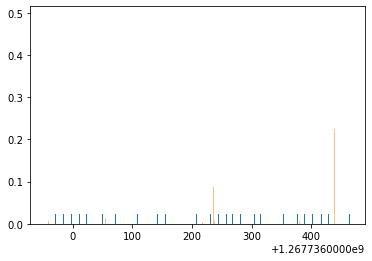

In [113]:
h, b, _ =plt.hist(injtime, bins=np.arange(gps_start_time, gps_end_time, 1),
        density=True);

plt.hist(time, bins=np.arange(gps_start_time, gps_end_time, 1),
        density=True, alpha=0.5);

# # Add annotations for each injection network_optimal_snr value
# for idx, snr_val in enumerate(injections["network_optimal_snr"]):
#     plt.annotate(f"{round(snr_val, 0)}", xy=(injtime[idx], 0.25), xytext=(injtime[idx], 0.26),
#                  arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)
plt.show()

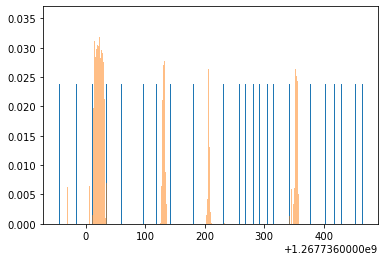

In [95]:
h, b, _ =plt.hist(injtime, bins=np.arange(gps_start_time, gps_end_time, 1),
        density=True);



plt.hist(triggers["network"]["mean_time"], bins=np.arange(gps_start_time, gps_end_time, 1),
        density=True, alpha=0.5);

# # Add annotations for each injection network_optimal_snr value
# for idx, snr_val in enumerate(injections["network_optimal_snr"]):
#     plt.annotate(f"{round(snr_val, 0)}", xy=(injtime[idx], 0.25), xytext=(injtime[idx], 0.26),
#                  arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)
plt.show()

(1267736195.0, 1267736210.0)

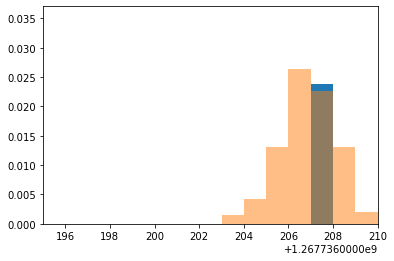

In [75]:
h, b, _ =plt.hist(injtime, bins=np.arange(gps_start_time, gps_end_time, 1),
        density=True);
plt.hist(triggers["network"]["mean_time"], bins=np.arange(gps_start_time, gps_end_time, 1),
        density=True, alpha=0.5);
xlow = 1267736195
xhi = 1267736210
plt.xlim(xlow, xhi)
# ii = np.where((b>xlow)&(b<xhi))

In [70]:
len(b), len(h)

(512, 511)

In [65]:
1267736200
1267736210
b

array([1267735954, 1267735955, 1267735956, 1267735957, 1267735958,
       1267735959, 1267735960, 1267735961, 1267735962, 1267735963,
       1267735964, 1267735965, 1267735966, 1267735967, 1267735968,
       1267735969, 1267735970, 1267735971, 1267735972, 1267735973,
       1267735974, 1267735975, 1267735976, 1267735977, 1267735978,
       1267735979, 1267735980, 1267735981, 1267735982, 1267735983,
       1267735984, 1267735985, 1267735986, 1267735987, 1267735988,
       1267735989, 1267735990, 1267735991, 1267735992, 1267735993,
       1267735994, 1267735995, 1267735996, 1267735997, 1267735998,
       1267735999, 1267736000, 1267736001, 1267736002, 1267736003,
       1267736004, 1267736005, 1267736006, 1267736007, 1267736008,
       1267736009, 1267736010, 1267736011, 1267736012, 1267736013,
       1267736014, 1267736015, 1267736016, 1267736017, 1267736018,
       1267736019, 1267736020, 1267736021, 1267736022, 1267736023,
       1267736024, 1267736025, 1267736026, 1267736027, 1267736

In [62]:
np.diff(np.where(h != 0 )[0])

array([14, 14, 13, 14, 11, 13, 14, 11, 11, 13, 13, 11, 11, 12, 11, 13, 13,
       13, 12, 14, 13, 11, 13, 14, 10, 13, 11, 13, 10, 14, 13, 11, 13, 11,
       11, 14, 15, 12, 11, 13, 11])

In [45]:
len(injtime), len(np.unique(injtime))

(42, 42)

In [47]:
np.diff(injtime)

array([13.30222344, 14.60528827, 13.18712544, 13.89718199, 10.98173118,
       13.01989818, 13.57017326, 11.4509933 , 10.4975667 , 13.70357132,
       12.76685882, 11.09844136, 10.32368183, 12.29418039, 11.13356709,
       12.47535682, 13.90796781, 12.90355754, 11.34219575, 13.86441445,
       13.40363431, 11.47400188, 12.78088498, 13.87402177, 10.3728826 ,
       12.49324799, 10.59998727, 13.00300288, 10.13164783, 14.44464779,
       12.64085078, 11.38991189, 13.25315213, 10.58472443, 10.73772502,
       14.69513822, 14.3602035 , 11.92428327, 10.91688037, 13.61600566,
       10.51025796])

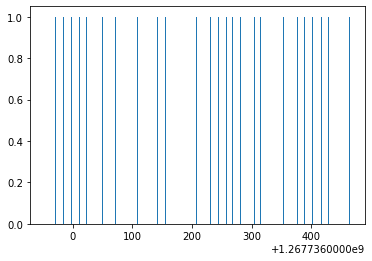

In [40]:
plt.hist(injtime, bins=np.arange(gps_start_time, gps_end_time, 1));

In [37]:
injections["mass1"]

array([154.48760224, 285.62387145, 302.27068628, 314.49633496,
       298.88367305, 178.06173026, 219.92031305, 435.32357284,
       546.07140433, 467.28407515, 176.8704786 , 271.08219497,
       390.18353103, 410.33315087, 252.97580288, 354.49857055,
       329.80425121,  97.00941954, 462.23790871, 509.19153454,
       266.49859882, 373.72776266, 128.01183272, 233.39651318,
       283.35473848, 337.51097904, 283.69023004, 461.46654288,
       186.60477356, 359.59112268, 495.25536125, 249.54069225,
       452.34238673, 160.23668031, 412.95983143, 410.45988109,
       197.87434519, 533.81674698, 248.80233695, 415.09785411,
       115.5801643 , 110.9789465 ])

In [ ]:
plt.hist(triggers["network"]["mean_time"], bins=np.arange(gps_start_time, gps_end_time, 1));

In [14]:
trigs["snr_2_filter"]

array([1.7774527e+04, 1.9013039e+04, 2.5919328e+04, 4.5677872e+02,
       1.7098184e+02, 2.5430820e+04, 8.2581081e+00, 2.4714334e+04,
       7.7105786e+02, 2.6249236e+04, 4.1486383e+02, 1.2289508e+01],
      dtype=float32)